# 4.2. Benchmarking: In-silico Models

### 📘 Overview

This notebook benchmarks our DILI prediction model against state-of-the-art in-silico models DILIPredictor, DILIGeNN and the recently released LLM from Google DeepMind - TxGemma Predict 2B, 9B, 27B variants.

**Important note**: To run this notebook, download the [reproducibility directory](https://dilimap.org/review-dUFZulWv8k7bERJ3FQs4/reproducibility.zip), which contains all required files and scripts.

**Outputs**: 
* **Figure 6B**
* **Benchmark summary**

In [1]:
%%capture
!pip install torch-geometric captum rdkit matplotlib_venn

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import random
import dilimap as dmap

from sklearn.metrics import (
    confusion_matrix,
    balanced_accuracy_score,
    recall_score,
)
import torch
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import inchi
from rdkit.Chem import AllChem, DataStructs

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [4]:
import rdkit

rdkit.__version__

'2023.09.2'

In [5]:
from insilico_benchmarks.graph_gen_diligenn import process_dili_data, clean_dili_data
from insilico_benchmarks.run_diligenn import (
    diligenn_predict_outer_folds,
    diligenn_predict_outer_folds_warm_starts,
    Graph_custom,
    GNNModel,
)

In [6]:
from sklearn.metrics import roc_auc_score
from matplotlib_venn import venn3, venn2

## 1. Utility functions

In [7]:
def smiles_to_inchikey14(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    inchikey = inchi.MolToInchiKey(mol)
    return inchikey[:14]  # return first 14 characters

In [8]:
def compute_tanimoto_similarity_matrix(
    list_of_smiles_1: pd.DataFrame,
    list_of_smiles_2: pd.DataFrame,
) -> np.ndarray:
    """
    Computes the Tanimoto similarity matrix between two sets of SMILES strings.

    Args:
        smiles_col1 (str): Column name for SMILES in df1.
        smiles_col2 (str): Column name for SMILES in df2.

    Returns:
        np.ndarray: Similarity matrix of shape (len(df1), len(df2)).
    """
    # Convert SMILES to RDKit Mol
    mols1 = [Chem.MolFromSmiles(s) for s in list_of_smiles_1]
    mols2 = [Chem.MolFromSmiles(s) for s in list_of_smiles_2]

    # Filter out None values
    valid1 = [(i, m) for i, m in enumerate(mols1) if m is not None]
    valid2 = [(j, m) for j, m in enumerate(mols2) if m is not None]

    if not valid1 or not valid2:
        return np.empty((0, 0))  # Return empty matrix if no valid inputs

    idx1, mols1_valid = zip(*valid1)
    idx2, mols2_valid = zip(*valid2)

    # Compute fingerprints
    fps1 = [AllChem.GetMorganFingerprintAsBitVect(m, 2) for m in mols1_valid]
    fps2 = [AllChem.GetMorganFingerprintAsBitVect(m, 2) for m in mols2_valid]

    # Compute similarity matrix
    sim_matrix = np.array(
        [DataStructs.BulkTanimotoSimilarity(fp1, fps2) for fp1 in fps1]
    )

    # Fill full matrix with NaNs for invalid entries
    full_matrix = np.full((len(list_of_smiles_1), len(list_of_smiles_2)), np.nan)
    for i, row in zip(idx1, sim_matrix):
        for j, val in zip(idx2, row):
            full_matrix[i, j] = val

    return full_matrix

In [9]:
def calculate_comprehensive_metrics(df, true_label_col, prediction_columns):
    """
    Calculate metrics for multiple models and create comparison table.

    Parameters:
    - df: DataFrame containing predictions
    - true_label_col: column name for true labels
    - prediction_columns: list of column names containing binary predictions

    Returns:
    - DataFrame with metrics comparison
    """

    y_true = df[true_label_col].astype(str)
    y_true_bool = (y_true == 'True').astype(bool)

    metrics_data = []

    for i, pred_col in enumerate(prediction_columns):
        if pred_col not in df.columns:
            continue

        # Handle different prediction formats
        if df[pred_col].dtype == 'bool':
            y_pred = df[pred_col]
        elif df[pred_col].dtype == 'object':
            y_pred = (df[pred_col].astype(str) == 'True').astype(bool)
        else:
            y_pred = df[pred_col].astype(bool)

        # Calculate metrics
        balanced_acc = balanced_accuracy_score(y_true_bool, y_pred)
        recall = recall_score(y_true_bool, y_pred)

        # Calculate specificity
        try:
            tn, fp, fn, tp = confusion_matrix(y_true_bool, y_pred).ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        except Exception:
            specificity = 0

        metrics_data.append(
            {
                'Model': pred_col.replace('_', ' ').title(),
                'Balanced Accuracy': round(balanced_acc, 3),
                'Specificity': round(specificity, 3),
                'Sensitivity': round(recall, 3),
                # 'F1-Score': round(f1, 3),
            }
        )

    return pd.DataFrame(metrics_data)

In [10]:
def plot_roc_curves(
    df, true_label_col, probability_columns, model_names=None, colors=None
):
    """
    Plot ROC curves for multiple models.

    Parameters:
    - df: DataFrame containing predictions
    - true_label_col: column name for true labels
    - probability_columns: list of column names containing probability scores
    - model_names: list of model names for legend (optional)
    - colors: list of colors for each curve (optional)
    """
    y_true = df[true_label_col].astype(str)
    y_true_bool = (y_true == 'True').astype(bool)

    if colors is None:
        colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']

    if model_names is None:
        model_names = [col.replace('_', ' ').title() for col in probability_columns]

    for i, (prob_col, model_name, color) in enumerate(
        zip(probability_columns, model_names, colors)
    ):
        if prob_col not in df.columns:
            continue

        try:
            y_prob = df[prob_col].astype(float)
            show_plot = i == len(probability_columns) - 1  # Show only on last iteration

            dmap.pl.roc_curve(
                y_true_bool, y_prob, label=model_name, color=color, show=show_plot
            )

        except Exception as e:
            print(f'Could not plot ROC curve for {model_name}: {e}')

In [11]:
def print_confusion_matrix_analysis(
    df, true_label_col='True_label', pred_label_col='Predicted_label'
):
    """
    Print value counts for true labels and calculate confusion matrix components.

    Parameters:
    df: DataFrame containing the predictions
    true_label_col: Column name for true labels
    pred_label_col: Column name for predicted labels
    """
    # Print value counts for True_label
    print('True_label distribution:')
    print(df[true_label_col].value_counts())

    # Calculate and print true positives and true negatives for ToxPredictor
    y_true = (df[true_label_col].astype(str) == 'True').astype(bool)
    y_pred = df[pred_label_col].astype(bool)

    # Calculate confusion matrix components
    tp = ((y_true == True) & (y_pred == True)).sum()
    tn = ((y_true == False) & (y_pred == False)).sum()

    print(f'\nConfusion matrix: for {pred_label_col}')
    print(
        f'True Positives (TP): {tp} / Total DILI {df[true_label_col].value_counts()["True"]}'
    )
    print(
        f'True Negatives (TN): {tn}/  Total Non-DILI {df[true_label_col].value_counts()["False"]}'
    )

In [12]:
def set_random_seeds(seed=42):
    """
    Set random seeds for reproducibility across numpy and torch.

    Parameters:
    seed: Random seed value (default: 42)
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        # Print all seeds in use
    print('Seeds currently in use:')
    print(f'PyTorch manual seed: {torch.initial_seed()}')
    print(f'NumPy random seed: {np.random.get_state()[1][0]}')
    print(f'CUDA deterministic: {torch.backends.cudnn.deterministic}')
    print(f'CUDA benchmark: {torch.backends.cudnn.benchmark}')
    return


set_random_seeds(seed=42)

Seeds currently in use:
PyTorch manual seed: 42
NumPy random seed: 42
CUDA deterministic: True
CUDA benchmark: False


## 2. DILImap results

In [13]:
# Pull model
model = dmap.models.ToxPredictor()

2025-07-28 12:01:25,474 - INFO - Found credentials in environment variables.
2025-07-28 12:01:26,548 - INFO - Found credentials in environment variables.
2025-07-28 12:01:27,406 - INFO - Found credentials in environment variables.


Package: s3://dilimap/public/models. Top hash: b119d5a238


2025-07-28 12:01:31,520 - INFO - Found credentials in environment variables.
2025-07-28 12:01:32,466 - INFO - Found credentials in environment variables.
2025-07-28 12:01:33,203 - INFO - Found credentials in environment variables.


Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


Package: s3://dilimap/public/models. Top hash: b119d5a238
AWS credentials not found in environment or .env file.
Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


In [14]:
# Get results from validation data
adata_val = dmap.datasets.DILImap_validation_data()
dmap.utils.map_dili_labels_and_cmax(adata_val)

df_res_margins_val = model.compute_safety_margin(adata_val)

2025-07-28 12:01:34,667 - INFO - Found credentials in environment variables.
2025-07-28 12:01:35,774 - INFO - Found credentials in environment variables.
2025-07-28 12:01:36,509 - INFO - Found credentials in environment variables.


Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


2025-07-28 12:01:38,316 - INFO - Found credentials in environment variables.
2025-07-28 12:01:39,443 - INFO - Found credentials in environment variables.
2025-07-28 12:01:40,154 - INFO - Found credentials in environment variables.


Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


2025-07-28 12:01:41,498 - INFO - Found credentials in environment variables.
2025-07-28 12:01:42,588 - INFO - Found credentials in environment variables.
2025-07-28 12:01:43,301 - INFO - Found credentials in environment variables.


Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


2025-07-28 12:01:44,615 - INFO - Found credentials in environment variables.
2025-07-28 12:01:45,713 - INFO - Found credentials in environment variables.
2025-07-28 12:01:46,445 - INFO - Found credentials in environment variables.


Package: s3://dilimap/public/data. Top hash: e5bf3de9d2
283 out of 469 features in your data are not present in the training data. These features will not impact predictions. You can access the features available in the training data via `model.features`.


In [15]:
# Concatenate cross-val and validation results
df_res_all = pd.concat(
    [
        model.cross_val_results.assign(Batch='cross-validation'),
        df_res_margins_val.assign(Batch='validation'),
    ],
    ignore_index=False,
)

In [16]:
# Map DILI label and smiles
dmap.utils.map_dili_labels_and_cmax(
    df_res_all,
    labels=['DILIrank', 'label_section', 'livertox_score', 'DILI_label', 'smiles'],
    insert_at_front=True,
)

df_res_all.loc['Auranofin', 'smiles'] = (
    'CCP(CC)CC.CC(=O)OC[C@@H]1[C@H]([C@@H]([C@H]([C@@H](O1)[S-])OC(=O)C)OC(=O)C)OC(=O)C.[Au+]'
)
df_res_all.loc['FIRU', 'smiles'] = (
    'O[C@H]1[C@@H](F)[C@H](N2C(NC(C(I)=C2)=O)=O)O[C@@H]1CO'
)

2025-07-28 12:01:48,700 - INFO - Found credentials in environment variables.
2025-07-28 12:01:49,875 - INFO - Found credentials in environment variables.
2025-07-28 12:01:50,540 - INFO - Found credentials in environment variables.


Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


In [17]:
# True vs. predicted labels
df_res_all['True_label'] = np.where(
    df_res_all['DILI_label'].isin(
        ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)']
    ),
    True,
    np.where(df_res_all['DILI_label'].isin(['No DILI']), False, ''),
)

df_res_all['Predicted_label'] = df_res_all['Classification'].map(
    {'+': True, '-': False}
)

df_res_all['compound_name'] = df_res_all.index.tolist()

In [18]:
len(df_res_all)

300

In [19]:
indices_true_false = df_res_all[
    df_res_all['True_label'].isin(['True', 'False'])
].index.tolist()
len(indices_true_false)

210

In [20]:
df_res_all.head()

,DILIrank,label_section,livertox_score,smiles,DILI_label,Cmax_uM,First_DILI_uM,MOS_Cytotoxicity,MOS_ToxPredictor,Primary_DILI_driver,Classification,Batch,True_label,Predicted_label,compound_name
compound_name,,,,,,,,,,,,,,,
Abacavir,Most-DILI-Concern,Warnings and precautions,C,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,DILI (likely),14.850000,333.333333,300.00000,22.446689,Transcriptomics,+,cross-validation,True,True,Abacavir
Acarbose,Most-DILI-Concern,Warnings and precautions,B,C[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O)[C@@H](O...,DILI (likely),0.112949,333.333333,300.00000,300.000000,none,-,cross-validation,True,False,Acarbose
Acebutolol,Less-DILI-Concern,Adverse reactions,C,CCCC(=O)Nc1ccc(OCC(O)CNC(C)C)c(C(C)=O)c1,DILI (few cases),2.737568,333.333000,300.00000,121.762455,none,-,cross-validation,,False,Acebutolol
Aceclofenac,Less-DILI-Concern,No match,NaN,O=C(O)COC(=O)Cc1ccccc1Nc1c(Cl)cccc1Cl,DILI (few cases),30.443705,100.000000,20.01169,3.284751,Transcriptomics,+,cross-validation,,True,Aceclofenac
Acetaminophen,Most-DILI-Concern,Warnings and precautions,A [HD],CC(=O)Nc1ccc(O)cc1,DILI (known),132.310000,NaN,300.00000,15.116015,Cmax,+,cross-validation,True,True,Acetaminophen


### Load DILI SMILES dataframe

In [21]:
all_cmpds = dmap.s3.read('compound_DILI_labels.csv')
all_cmpds.source.value_counts()
all_cmpds.loc['Auranofin', 'smiles'] = (
    'CCP(CC)CC.CC(=O)OC[C@@H]1[C@H]([C@@H]([C@H]([C@@H](O1)[S-])OC(=O)C)OC(=O)C)OC(=O)C.[Au+]'
)
all_cmpds.loc['FIRU', 'smiles'] = (
    'O[C@H]1[C@@H](F)[C@H](N2C(NC(C(I)=C2)=O)=O)O[C@@H]1CO'
)

cellarity_smiles_dili_dataset = all_cmpds[
    (
        (all_cmpds['DILI_label_binary'].notna())
        &
        #  (all_cmpds['DILIrank'].notna()) &
        (all_cmpds['smiles'].notna())
    )
    # (all_cmpds['compound_name'].isin(specific_compounds))
].copy()

cellarity_smiles_dili_dataset.DILI_label_binary.value_counts()

2025-07-28 12:01:52,160 - INFO - Found credentials in environment variables.
2025-07-28 12:01:53,308 - INFO - Found credentials in environment variables.
2025-07-28 12:01:54,056 - INFO - Found credentials in environment variables.


Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


DILI_label_binary
No DILI    712
DILI       339
Name: count, dtype: int64

DILI_label_binary
No DILI    712
DILI       339
Name: count, dtype: int64

## 3. Run DILIGeNN on validation set

### 3.1 Load data and identify unseen subset using InChiKey14, Compound Name and SMILES

In [22]:
df_dg = pd.read_csv('./insilico_benchmarks/smiles_data/DILIGeNN_seen_1167.csv')
df_dg.head()

,DILIST_ID,name,label,Routs of Administration,smiles,smiles_pcp,error_msg,smiles_std
0,1,mercaptopurine,1,Oral,C1=NC2=C(N1)C(=S)N=CN2,C1=NC2=C(N1)C(=S)N=CN2,Success,S=c1[nH]cnc2[nH]cnc12
1,2,acetaminophen,1,Oral,CC(=O)NC1=CC=C(C=C1)O,CC(=O)NC1=CC=C(C=C1)O,Success,CC(=O)Nc1ccc(O)cc1
2,3,azathioprine,1,Oral,CN1C=NC(=C1SC2=NC=NC3=C2NC=N3)[N+](=O)[O-],CN1C=NC(=C1SC2=NC=NC3=C2NC=N3)[N+](=O)[O-],Success,Cn1cnc([N+](=O)[O-])c1Sc1ncnc2[nH]cnc12
3,4,chlorpheniramine,0,Oral,CN(C)CCC(C1=CC=C(C=C1)Cl)C2=CC=CC=N2,CN(C)CCC(C1=CC=C(C=C1)Cl)C2=CC=CC=N2,Success,CN(C)CCC(c1ccc(Cl)cc1)c1ccccn1
4,5,clofibrate,1,Oral,CCOC(=O)C(C)(C)OC1=CC=C(C=C1)Cl,CCOC(=O)C(C)(C)OC1=CC=C(C=C1)Cl,Success,CCOC(=O)C(C)(C)Oc1ccc(Cl)cc1


In [23]:
cellarity_smiles_dili_dataset.head()

,LTKBID,compound_name,DILIrank,label_section,severity_class,DILIst,roa,source,livertox_score,livertox_primary_classification,...,pathway,information,CAS_number,DMSO_mM_solubility,DILI_label,DILI_label_binary,DILI_label_section,livertox_updated,livertox_iDILI,livertox_mechanism_summary
4-aminosalicylic acid,LT00505,4-aminosalicylic acid,Most-DILI-Concern,Warnings and precautions,5.0,NaN,Oral,DILIrank,NaN,NaN,...,Microbiology,4-Aminosalicylic acid (Para-aminosalicylic aci...,65-49-6,65.3,DILI (likely),DILI,Likely,NaN,NaN,NaN
Abacavir,LT00040,Abacavir,Most-DILI-Concern,Warnings and precautions,8.0,NaN,Oral,DILIrank,C,Antimicrobial,...,Microbiology,"Abacavir (1592U89, ABC) is a powerful nucleosi...",136470-78-5,199.07,DILI (likely),DILI,Likely,2016 Jan 4,NaN,"Hepatitis, Cholestasis/Biliary, Hypersensitivi..."
Acarbose,LT01034,Acarbose,Most-DILI-Concern,Warnings and precautions,8.0,NaN,Oral,DILIrank,B,Endocrine,...,Metabolism,"Acarbose(BAY g 5421,Prandase, Precose, Glucoba...",56180-94-0,154.89,DILI (likely),DILI,Likely,2021 Jan 10,NaN,"Hepatitis, Cholestasis/Biliary, Immune-mediate..."
Acetaminophen,LT00004,Acetaminophen,Most-DILI-Concern,Warnings and precautions,5.0,NaN,Oral,DILIrank,A [HD],Analgesic,...,Neuronal Signaling,Acetaminophen is a COX inhibitor for COX-1 and...,103-90-2,198.47,DILI (known),DILI,Known,2016 Jan 28,NaN,"CYP, Hypersensitivity"
Acetazolamide,LT00498,Acetazolamide,Most-DILI-Concern,Warnings and precautions,8.0,NaN,Oral,DILIrank,D,Cardiovascular,...,Metabolism,"Acetazolamide (Diamox), a potent carbonic anhy...",59-66-5,197.98,DILI (likely),DILI,Likely,NaN,NaN,NaN


In [24]:
cellarity_smiles_dili_dataset['InChiKey14'] = [
    smiles_to_inchikey14(smiles) for smiles in cellarity_smiles_dili_dataset['smiles']
]
df_dg['InChiKey14'] = [smiles_to_inchikey14(smiles) for smiles in df_dg['smiles_std']]

In [25]:
# 1. Direct SMILES matching (intersection)
smiles_overlap_values = set(cellarity_smiles_dili_dataset['smiles']).intersection(
    set(df_dg['smiles'])
)
smiles_overlap_mask = cellarity_smiles_dili_dataset['smiles'].isin(
    smiles_overlap_values
)

# 1b. Direct SMILES matching for standardized SMILES (intersection)
if 'smiles_std' in df_dg.columns:
    smiles_std_overlap_values = set(
        cellarity_smiles_dili_dataset['smiles']
    ).intersection(set(df_dg['smiles_std']))
    smiles_std_overlap_mask = cellarity_smiles_dili_dataset['smiles'].isin(
        smiles_std_overlap_values
    )
else:
    smiles_std_overlap_mask = pd.Series(
        False, index=cellarity_smiles_dili_dataset.index
    )

# 2. Name matching (case-insensitive, intersection)
cellarity_names_lower = (
    cellarity_smiles_dili_dataset['compound_name'].astype(str).str.lower()
)
df_dg_names_lower = df_dg['name'].astype(str).str.lower()
name_overlap_values = set(cellarity_names_lower).intersection(set(df_dg_names_lower))
name_overlap_mask = cellarity_names_lower.isin(name_overlap_values)

# 3. InChiKey14 based overlap (intersection)
cellarity_inchikey14_lower = (
    cellarity_smiles_dili_dataset['InChiKey14'].astype(str).str.lower()
)
df_dg_inchikey14_lower = df_dg['InChiKey14'].astype(str).str.lower()
inchikey14_overlap_values = set(cellarity_inchikey14_lower).intersection(
    set(df_dg_inchikey14_lower)
)
inchikey14_overlap_mask = cellarity_inchikey14_lower.isin(inchikey14_overlap_values)

# Combine all overlap masks
overlap_mask = (
    smiles_overlap_mask
    | smiles_std_overlap_mask
    | name_overlap_mask
    | inchikey14_overlap_mask
)

# Subset to compounds that do NOT overlap
diligenn_unseeen_smiles = cellarity_smiles_dili_dataset[~overlap_mask].copy()

print(f'Unseen compounds: {len(diligenn_unseeen_smiles)}')

Unseen compounds: 349


In [26]:
diligenn_unseeen_smiles.head()

,LTKBID,compound_name,DILIrank,label_section,severity_class,DILIst,roa,source,livertox_score,livertox_primary_classification,...,information,CAS_number,DMSO_mM_solubility,DILI_label,DILI_label_binary,DILI_label_section,livertox_updated,livertox_iDILI,livertox_mechanism_summary,InChiKey14
Anagrelide,LT00964,Anagrelide,Ambiguous DILI-concern,Warnings and precautions,3.0,NaN,NaN,DILIrank,E*,Hematologic,...,NaN,NaN,NaN,No DILI,No DILI,No DILI,2017 Jul 5,NaN,NaN,OTBXOEAOVRKTNQ
Aprepitant,LT01195,Aprepitant,Ambiguous DILI-concern,Adverse reactions,3.0,NaN,NaN,DILIrank,E,Gastrointestinal,...,"Aprepitant (MK-0869, L-754030, Emend) is a pot...",170729-80-3,200.21,No DILI,No DILI,No DILI,2024 Feb 28,NaN,NaN,ATALOFNDEOCMKK
Bacitracin,LT02059,Bacitracin,No-DILI-Concern,No match,0.0,NaN,Intramuscular,DILIrank,NaN,NaN,...,Bacitracin is a mixture of related cyclic poly...,1405-87-4,NaN,No DILI,No DILI,No DILI,NaN,NaN,NaN,CLKOFPXJLQSYAH
Bortezomib,LT01202,Bortezomib,Most-DILI-Concern,Warnings and precautions,7.0,NaN,Intravenous,DILIrank,C,Antineoplastic,...,"Bortezomib (PS-341, Velcade, LDP-341, MLM341, ...",179324-69-7,197.79,DILI (likely),DILI,Likely,2017 Sep 30,NaN,"Hepatitis, Necrosis, CYP, Cholestasis/Biliary",GXJABQQUPOEUTA
Butabarbital,LT00707,Butabarbital,Ambiguous DILI-concern,Adverse reactions,3.0,NaN,NaN,DILIrank,E,CNS,...,NaN,NaN,NaN,No DILI,No DILI,No DILI,NaN,NaN,NaN,ZRIHAIZYIMGOAB


In [27]:
diligenn_unseeen_smiles['label'] = diligenn_unseeen_smiles['DILI_label_binary'].map(
    {'DILI': 1, 'No DILI': 0}
)
# diligenn_unseeen_smiles.to_csv('./insilico_benchmarks/smiles_data/unseen_smiles_diligenn_349.csv')

In [28]:
df_res_all[df_res_all.index.isin(diligenn_unseeen_smiles.index)]

,DILIrank,label_section,livertox_score,smiles,DILI_label,Cmax_uM,First_DILI_uM,MOS_Cytotoxicity,MOS_ToxPredictor,Primary_DILI_driver,Classification,Batch,True_label,Predicted_label,compound_name
compound_name,,,,,,,,,,,,,,,
Hydroxyzine,No-DILI-Concern,No match,E,OCCOCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1,No DILI,0.196691,1000.000000,300.000000,300.000000,none,-,cross-validation,False,False,Hydroxyzine
AKN-028,NaN,NaN,NaN,Nc1ncc(-c2ccncc2)nc1Nc1ccc2[nH]ccc2c1,DILI (withdrawn),1.000000,16.666667,300.000000,16.666667,Transcriptomics,+,validation,True,True,AKN-028
BMS-986142,NaN,NaN,NaN,Cc1c(-c2c(F)cc(C(N)=O)c3[nH]c4c(c23)CC[C@H](C(...,DILI (withdrawn),1.887880,3.703704,300.000000,1.961832,Transcriptomics,+,validation,True,True,BMS-986142
Evobrutinib,NaN,NaN,NaN,C=CC(=O)N1CCC(CNc2ncnc(N)c2-c2ccc(Oc3ccccc3)cc...,DILI (withdrawn),1.292170,1.851000,300.000000,1.432474,Transcriptomics,+,validation,True,True,Evobrutinib
Orelabrutinib,NaN,NaN,NaN,C=CC(=O)N1CCC(c2ccc(C(N)=O)c(-c3ccc(Oc4ccccc4)...,DILI (withdrawn),4.509942,33.333333,221.732365,7.391079,Transcriptomics,+,validation,True,True,Orelabrutinib
TAK-875,NaN,NaN,NaN,Cc1cc(OCCCS(C)(=O)=O)cc(C)c1-c1cccc(COc2ccc3c(...,DILI (withdrawn),2.382632,1.851852,83.940800,1.000000,Transcriptomics,+,validation,True,True,TAK-875
Tofacitinib,NaN,NaN,E*,C[C@@H]1CCN(C(=O)CC#N)C[C@@H]1N(C)c1ncnc2[nH]c...,No DILI,0.137977,33.333333,300.000000,241.585460,none,-,validation,False,False,Tofacitinib
Upadacitinib,NaN,NaN,D,CC[C@@H]1CN(C(=O)NCC(F)(F)F)C[C@@H]1c1cnc2cnc3...,No DILI,0.215563,100.000000,300.000000,300.000000,none,-,validation,False,False,Upadacitinib


In [29]:
# diligenn_truly_unseen.to_csv('./insilico_benchmarks/smiles_data/diligenn_unseen_std_cleaned.csv')

### 3.2 Graph pre-processing SMILES, Loading best models and running predictions using reproducible script

**Standardize Smiles and Run predictions**

In [30]:
## Standardize the Smiles before graph generation
standardized_df = process_dili_data(diligenn_unseeen_smiles, smiles_col='smiles')

df_std_filtered = clean_dili_data(
    standardized_df, smiles_col='smiles', label_col='label'
)
# Location of saved data object: insilico_benchmark/data/diligenn

Initial dataset size: 349
Compounds with missing SMILES: 0 (0.0%)
After removing missing SMILES: 349


Processing molecules: 100%|███████████████████| 349/349 [00:43<00:00,  7.97it/s]

Standardised dataset size: 349
Compounds failed standardization: 18 (5.2%)
After standardization filtering: 331
Compounds failed conformer generation: 0 (0.0%)
Error indices: []
Final cleaned dataset size: 331
Total compounds filtered out: 18 (5.2%)


In [31]:
set_random_seeds(seed=42)

Seeds currently in use:
PyTorch manual seed: 42
NumPy random seed: 42
CUDA deterministic: True
CUDA benchmark: False


**Predictions with warm starts**

In [32]:
diligenn_true_unseen_smiles_warmstart = diligenn_predict_outer_folds_warm_starts(
    df_std_filtered,
    dataset_class=Graph_custom,
    model_name='GraphSAGE_Optimised',
    model_class=GNNModel,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    model_selection_strategy='last_inner_fold',
)

For model GCN, mean val_auc of optimal hyperparameters across 20 inner folds: 0.627 ± 0.034
For model GAT, mean val_auc of optimal hyperparameters across 20 inner folds: 0.627 ± 0.031
For model GraphSAGE, mean val_auc of optimal hyperparameters across 20 inner folds: 0.624 ± 0.032
For model GIN, mean val_auc of optimal hyperparameters across 20 inner folds: 0.626 ± 0.032


100%|█████████████████████████████████████████| 331/331 [03:04<00:00,  1.79it/s]


Using models from last significant run: 3
Selected last inner fold 4 for outer fold 0
Selected last inner fold 4 for outer fold 1
Selected last inner fold 4 for outer fold 2
Selected last inner fold 4 for outer fold 3


**Predictions with base model**

In [33]:
diligenn_true_unseen_smiles_base = diligenn_predict_outer_folds(
    df_std_filtered,
    dataset_class=Graph_custom,
    model_name='GraphSAGE_Optimised',
    model_class=GNNModel,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)

For model GCN, mean val_auc of optimal hyperparameters across 20 inner folds: 0.627 ± 0.034
For model GAT, mean val_auc of optimal hyperparameters across 20 inner folds: 0.627 ± 0.031
For model GraphSAGE, mean val_auc of optimal hyperparameters across 20 inner folds: 0.624 ± 0.032
For model GIN, mean val_auc of optimal hyperparameters across 20 inner folds: 0.626 ± 0.032


100%|█████████████████████████████████████████| 331/331 [02:59<00:00,  1.84it/s]


In [34]:
print(
    f'DILIGeNN warm start filtered shape: {diligenn_true_unseen_smiles_warmstart.shape}'
)
print(f'DILIGeNN base filtered shape: {diligenn_true_unseen_smiles_base.shape}')

DILIGeNN warm start filtered shape: (331, 72)
DILIGeNN base filtered shape: (331, 72)


In [35]:
# Define columns to merge
prob_cols = ['prob_outer0', 'prob_outer1', 'prob_outer2', 'prob_outer3']
label_cols = ['label_outer0', 'label_outer1', 'label_outer2', 'label_outer3']

# Prepare base model columns with suffix
cols = prob_cols + label_cols
base_renamed = {col: f'{col}_base' for col in cols}  # keep for reference
diligenn_base_renamed = diligenn_true_unseen_smiles_base.rename(columns=base_renamed)


warmstart_renamed = {col: f'{col}_warmstart' for col in prob_cols + label_cols}
diligenn_warmstart_renamed = diligenn_true_unseen_smiles_warmstart[cols].rename(
    columns=warmstart_renamed
)

# Merge on index (assumes same order and index)
combined_df = pd.concat([diligenn_base_renamed, diligenn_warmstart_renamed], axis=1)
# Calculate average probabilities and mode predictions for each model
for model in ['base', 'warmstart']:
    combined_df[f'DILIGeNN_avg_prob_{model}'] = combined_df[
        [f'prob_outer{i}_{model}' for i in range(4)]
    ].mean(axis=1)
    label_cols_model = [f'label_outer{i}_{model}' for i in range(4)]
    combined_df[f'DILIGeNN_mode_pred_{model}'] = combined_df[label_cols_model].mode(
        axis=1
    )[0]

combined_df['True_label'] = combined_df['DILI_label_binary'].map(
    {'DILI': True, 'No DILI': False}
)
label_mapping = {'DILI': 1, 'No DILI': 0}
combined_df['True_label_numeric'] = combined_df['DILI_label_binary'].map(label_mapping)
# combined_df.to_csv('./insilico_benchmarks/predictions/benchmark_diligenn_331_predictions.csv')

**Load predictions**

In [36]:
combined_df = pd.read_csv(
    './insilico_benchmarks/predictions/benchmark_diligenn_331_predictions.csv',
    index_col=0,
)

In [37]:
combined_df.DILI_label_binary.value_counts()

DILI_label_binary
No DILI    284
DILI        47
Name: count, dtype: int64

### 3.3 Evaluate DILIGeNN GraphSage (warm-start) models on (potentially) unseen data (331 compounds)


Warm Start Model Performance Across Outer Folds:


,Model,Balanced Accuracy,Specificity,Sensitivity
0,Label Outer0 Warmstart,0.595,0.254,0.936
1,Label Outer1 Warmstart,0.467,0.296,0.638
2,Label Outer2 Warmstart,0.516,0.116,0.915
3,Label Outer3 Warmstart,0.593,0.292,0.894



Base Model Performance Across Outer Folds:


,Model,Balanced Accuracy,Specificity,Sensitivity
0,Label Outer0 Base,0.552,0.254,0.851
1,Label Outer1 Base,0.470,0.366,0.574
2,Label Outer2 Base,0.498,0.165,0.830
3,Label Outer3 Base,0.520,0.401,0.638



Final Performance Comparison:


,Model,Balanced Accuracy,Specificity,Sensitivity
0,DILIGeNN Warm Start (GraphSAGE),0.543 ± 0.062,0.239 ± 0.084,0.846 ± 0.140
1,DILIGeNN Base (GraphSAGE),0.510 ± 0.035,0.296 ± 0.108,0.723 ± 0.138


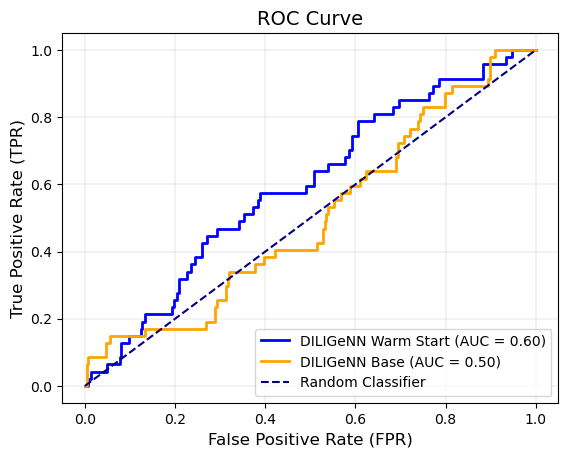

In [38]:
def get_performance(df, model_prefix):
    label_cols = [f'label_outer{i}_{model_prefix}' for i in range(4)]
    return calculate_comprehensive_metrics(df, 'True_label', label_cols)


warmstart_performance = get_performance(combined_df, 'warmstart')
base_performance = get_performance(combined_df, 'base')

print('\nWarm Start Model Performance Across Outer Folds:')
display(warmstart_performance)

print('\nBase Model Performance Across Outer Folds:')
display(base_performance)

# Create summary statistics
warmstart_numeric_cols = warmstart_performance.select_dtypes(
    include=[np.number]
).columns
base_numeric_cols = base_performance.select_dtypes(include=[np.number]).columns

warmstart_summary = pd.DataFrame(
    {
        'Model': ['DILIGeNN Warm Start (GraphSAGE)'],
        **{
            col: [
                f'{warmstart_performance[col].mean():.3f} ± {warmstart_performance[col].std():.3f}'
            ]
            for col in warmstart_numeric_cols
        },
    }
)

base_summary = pd.DataFrame(
    {
        'Model': ['DILIGeNN Base (GraphSAGE)'],
        **{
            col: [
                f'{base_performance[col].mean():.3f} ± {base_performance[col].std():.3f}'
            ]
            for col in base_numeric_cols
        },
    }
)

final_comparison_df = pd.concat([warmstart_summary, base_summary], ignore_index=True)
print('\nFinal Performance Comparison:')
display(final_comparison_df)

# Plot ROC curves for both models
plot_roc_curves(
    combined_df,
    'True_label',
    ['DILIGeNN_avg_prob_warmstart', 'DILIGeNN_avg_prob_base'],
    model_names=['DILIGeNN Warm Start', 'DILIGeNN Base'],
)

### 3.4 Benchmarking DILIGeNN GraphSage (warm-start) model against ToxPredictor (8 compounds)

In [39]:
overlap_with_df_res_all = set(combined_df['compound_name']).intersection(
    set(df_res_all['compound_name'])
)
len(overlap_with_df_res_all)

8

In [40]:
df_res_all_subset = df_res_all[
    ~(
        (df_res_all.compound_name == 'Chlorpromazine')
        & (df_res_all.Batch == 'cross-validation')
    )
].copy()
df_res_all_subset = df_res_all_subset[
    df_res_all_subset.index.isin(overlap_with_df_res_all)
].copy()
df_res_all_subset.head()

,DILIrank,label_section,livertox_score,smiles,DILI_label,Cmax_uM,First_DILI_uM,MOS_Cytotoxicity,MOS_ToxPredictor,Primary_DILI_driver,Classification,Batch,True_label,Predicted_label,compound_name
compound_name,,,,,,,,,,,,,,,
Hydroxyzine,No-DILI-Concern,No match,E,OCCOCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1,No DILI,0.196691,1000.000000,300.000000,300.000000,none,-,cross-validation,False,False,Hydroxyzine
AKN-028,NaN,NaN,NaN,Nc1ncc(-c2ccncc2)nc1Nc1ccc2[nH]ccc2c1,DILI (withdrawn),1.000000,16.666667,300.000000,16.666667,Transcriptomics,+,validation,True,True,AKN-028
BMS-986142,NaN,NaN,NaN,Cc1c(-c2c(F)cc(C(N)=O)c3[nH]c4c(c23)CC[C@H](C(...,DILI (withdrawn),1.887880,3.703704,300.000000,1.961832,Transcriptomics,+,validation,True,True,BMS-986142
Evobrutinib,NaN,NaN,NaN,C=CC(=O)N1CCC(CNc2ncnc(N)c2-c2ccc(Oc3ccccc3)cc...,DILI (withdrawn),1.292170,1.851000,300.000000,1.432474,Transcriptomics,+,validation,True,True,Evobrutinib
Orelabrutinib,NaN,NaN,NaN,C=CC(=O)N1CCC(c2ccc(C(N)=O)c(-c3ccc(Oc4ccccc4)...,DILI (withdrawn),4.509942,33.333333,221.732365,7.391079,Transcriptomics,+,validation,True,True,Orelabrutinib


In [41]:
diligenn_dmap = combined_df.copy()
diligenn_dmap = diligenn_dmap[
    diligenn_dmap.compound_name.isin(overlap_with_df_res_all)
].copy()

# Update diligenn_dmap with values from df_res_all
for col in ['True_label', 'Predicted_label', 'MOS_ToxPredictor']:
    diligenn_dmap[col] = diligenn_dmap['compound_name'].map(
        df_res_all_subset.set_index('compound_name')[col]
    )

diligenn_dmap['ToxPredictor_Inverse_MOS'] = 1 / diligenn_dmap['MOS_ToxPredictor']
diligenn_dmap.head()

,LTKBID,compound_name,DILIrank,label_section,severity_class,DILIst,roa,source,livertox_score,livertox_primary_classification,...,label_outer1_warmstart,label_outer2_warmstart,label_outer3_warmstart,DILIGeNN_avg_prob_warmstart,DILIGeNN_mode_pred_warmstart,True_label,True_label_numeric,Predicted_label,MOS_ToxPredictor,ToxPredictor_Inverse_MOS
26,LT01437,Hydroxyzine,No-DILI-Concern,No match,0.0,NaN,NaN,DILIrank,E,Respiratory,...,0,1,0,0.370794,0.0,False,0,False,300.000000,0.003333
49,NaN,AKN-028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,0.991106,1.0,True,1,True,16.666667,0.060000
69,NaN,BMS-986142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,0.998426,1.0,True,1,True,1.961832,0.509728
143,NaN,Evobrutinib,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,0.992263,1.0,True,1,True,1.432474,0.698093
220,NaN,Orelabrutinib,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,0.995653,1.0,True,1,True,7.391079,0.135298


In [42]:
diligenn_dmap.True_label.value_counts()

True_label
True     5
False    3
Name: count, dtype: int64

In [43]:
def get_performance(df, model_prefix):
    label_cols = [f'label_outer{i}_{model_prefix}' for i in range(4)]
    return calculate_comprehensive_metrics(df, 'True_label', label_cols)


warmstart_performance = get_performance(diligenn_dmap, 'warmstart')

print('\nWarm Start Model Performance Across Outer Folds:')
display(warmstart_performance)

# Calculate ToxPredictor performance using Predicted_label
toxpredictor_performance = calculate_comprehensive_metrics(
    diligenn_dmap, 'True_label', ['Predicted_label']
)

print('\nToxPredictor Performance:')
display(toxpredictor_performance)

# Create summary statistics
warmstart_numeric_cols = warmstart_performance.select_dtypes(
    include=[np.number]
).columns

warmstart_summary = pd.DataFrame(
    {
        'Model': ['DILIGeNN Warm Start (GraphSAGE)'],
        **{
            col: [
                f'{warmstart_performance[col].mean():.3f} ± {warmstart_performance[col].std():.3f}'
            ]
            for col in warmstart_numeric_cols
        },
    }
)

toxpredictor_summary = pd.DataFrame(
    {
        'Model': ['ToxPredictor'],
        **{
            col: [f'{toxpredictor_performance[col].iloc[0]:.3f}']
            for col in warmstart_numeric_cols
        },
    }
)

final_comparison_df = pd.concat(
    [toxpredictor_summary, warmstart_summary], ignore_index=True
)
print('\nFinal Performance Comparison:')
display(final_comparison_df)


Warm Start Model Performance Across Outer Folds:


,Model,Balanced Accuracy,Specificity,Sensitivity
0,Label Outer0 Warmstart,0.667,0.333,1.0
1,Label Outer1 Warmstart,0.667,0.333,1.0
2,Label Outer2 Warmstart,0.667,0.333,1.0
3,Label Outer3 Warmstart,1.000,1.000,1.0



ToxPredictor Performance:


,Model,Balanced Accuracy,Specificity,Sensitivity
0,Predicted Label,1.0,1.0,1.0



Final Performance Comparison:


,Model,Balanced Accuracy,Specificity,Sensitivity
0,ToxPredictor,1.000,1.000,1.000
1,DILIGeNN Warm Start (GraphSAGE),0.750 ± 0.166,0.500 ± 0.334,1.000 ± 0.000


In [44]:
print_confusion_matrix_analysis(
    diligenn_dmap,
    true_label_col='True_label',
    pred_label_col='DILIGeNN_mode_pred_warmstart',
)
print_confusion_matrix_analysis(diligenn_dmap)

True_label distribution:
True_label
True     5
False    3
Name: count, dtype: int64

Confusion matrix: for DILIGeNN_mode_pred_warmstart
True Positives (TP): 5 / Total DILI 5
True Negatives (TN): 2/  Total Non-DILI 3
True_label distribution:
True_label
True     5
False    3
Name: count, dtype: int64

Confusion matrix: for Predicted_label
True Positives (TP): 5 / Total DILI 5
True Negatives (TN): 3/  Total Non-DILI 3


## 4. DILIPRedictor

### 4.1 Load data and identify unseen subset using InChiKey14, Compound Name and SMILES

In [45]:
dilirank_dp = pd.read_csv(
    './insilico_benchmarks/smiles_data/DILIPredictor_seen_1111.csv'
)
dilirank_dp.head()

,smiles_r,TOXICITY,Source_rank,Source,Data,InChIKey,InChIKey14,protonated_smiles_r
0,C#Cc1cccc(N=c2[nH]cnc3cc(OCCOC)c(OCCOC)cc23)c1,1,1,DILIst Classification Oral,DILI,AAKJLRGGTJKAMG-UHFFFAOYSA-N,AAKJLRGGTJKAMG,C#Cc1cccc(N=c2[nH]cnc3cc(OCCOC)c(OCCOC)cc23)c1
1,COC1(NC(=O)CSC(F)F)C(=O)N2C(C(=O)O)=C(CSc3nnnn...,1,1,DILIst Classification,DILI,UHRBTBZOWWGKMK-UHFFFAOYSA-N,UHRBTBZOWWGKMK,COC1(NC(=O)CSC(F)F)C(=O)[NH+]2C(C(=O)[O-])=C(C...
2,CC(C)COCC(CN(Cc1ccccc1)c1ccccc1)N1CCCC1,1,1,DILIst Classification,DILI,UIEATEWHFDRYRU-UHFFFAOYSA-N,UIEATEWHFDRYRU,CC(C)COCC(CN(Cc1ccccc1)c1ccccc1)[NH+]1CCCC1
3,Cc1onc(-c2c(F)cccc2Cl)c1C(=O)NC1C(=O)N2C1SC(C)...,1,1,DILIst Classification oral,DILI,UIOFUWFRIANQPC-UHFFFAOYSA-N,UIOFUWFRIANQPC,Cc1onc(-c2c(F)cccc2Cl)c1C(=O)NC1C(=O)[NH+]2C1S...
4,CC1OC1[P](=O)(=O)O,1,1,DILIst Classification Oral,DILI,UJNUDOLLRRCQDH-UHFFFAOYSA-N,UJNUDOLLRRCQDH,CC1OC1[P](=O)(=O)O


In [46]:
# 1. Direct SMILES matching (intersection)
smiles_overlap_values = set(cellarity_smiles_dili_dataset['smiles']).intersection(
    set(dilirank_dp['smiles_r'])
)
smiles_overlap_mask = cellarity_smiles_dili_dataset['smiles'].isin(
    smiles_overlap_values
)

# 1b. Direct SMILES matching for protonated SMILES (intersection)
smiles_proto_overlap_values = set(cellarity_smiles_dili_dataset['smiles']).intersection(
    set(dilirank_dp['protonated_smiles_r'])
)
smiles_proto_overlap_mask = cellarity_smiles_dili_dataset['smiles'].isin(
    smiles_proto_overlap_values
)

# 2. InChiKey14 based overlap (intersection)
cellarity_inchikey14_lower = cellarity_smiles_dili_dataset['InChiKey14'].astype(str)
dilirank_dp_inchikey14_lower = dilirank_dp['InChIKey14'].astype(str)
inchikey14_overlap_values = set(cellarity_inchikey14_lower).intersection(
    set(dilirank_dp_inchikey14_lower)
)
inchikey14_overlap_mask = cellarity_inchikey14_lower.isin(inchikey14_overlap_values)

# Combine all overlap masks
overlap_mask = smiles_overlap_mask | smiles_proto_overlap_mask | inchikey14_overlap_mask

# Subset to compounds that do NOT overlap
dilipr_unseeen_smiles = cellarity_smiles_dili_dataset[~overlap_mask].copy()

print(f'Unseen compounds: {len(dilipr_unseeen_smiles)}')

Unseen compounds: 483


In [47]:
dilipr_unseeen_smiles['label'] = dilipr_unseeen_smiles['DILI_label_binary'].map(
    {'DILI': 1, 'No DILI': 0}
)
# dilipr_unseeen_smiles.to_csv('./insilico_benchmarks/smiles_data/unseen_smiles_dilipr_483.csv')

### 4.2 Run predictions using reproducible scripts

Run this command in terminal and follow the instructions as recommended by the code `python ./insilico_benchmarks/run_dilipredictor.py -i ./insilico_benchmarks/smiles_data/unseen_smiles_dilipr_483.csv  -o ./insilico_benchmarks/predictions/benchmark_dilipr_483_model_output.csv`

In [48]:
dilipr_test_pred = pd.read_csv(
    './insilico_benchmarks/predictions/benchmark_dilipr_483_model_output.csv'
)
dilipr_predictions = dilipr_unseeen_smiles.copy()
dilipr_predictions['DILIPredictor_prediction'] = dilipr_test_pred[
    'DILIPRedictor_prediction'
].tolist()
dilipr_predictions['DILIPredictor_binary'] = (
    dilipr_predictions['DILIPredictor_prediction'] == 'DILI'
)
dilipr_predictions['DILIPredictor_probability'] = dilipr_test_pred[
    'DILIPRedictor_probability'
].tolist()
# dilipr_predictions.to_csv('predictions/benchmark_dilipr_483_predictions.csv')
dilipr_predictions.head()

,LTKBID,compound_name,DILIrank,label_section,severity_class,DILIst,roa,source,livertox_score,livertox_primary_classification,...,DILI_label_binary,DILI_label_section,livertox_updated,livertox_iDILI,livertox_mechanism_summary,InChiKey14,label,DILIPredictor_prediction,DILIPredictor_binary,DILIPredictor_probability
Acetylcholine chloride,LT02096,Acetylcholine chloride,No-DILI-Concern,No match,0.0,NaN,Oral,DILIrank,NaN,NaN,...,No DILI,No DILI,NaN,NaN,NaN,JUGOREOARAHOCO,0,No DILI,False,0.3382606667842065
Alatrofloxacin mesylate,LT00461,Alatrofloxacin mesylate,Most-DILI-Concern,Withdrawn,8.0,NaN,Oral,DILIrank,NaN,NaN,...,DILI,Withdrawn,NaN,NaN,NaN,CYETUYYEVKNSHZ,1,DILI,True,0.7504044838184715
Allopurinol,LT00043,Allopurinol,Most-DILI-Concern,Warnings and precautions,8.0,NaN,Oral,DILIrank,A,Rheumatologic,...,DILI,Known,2020 Dec 26,NaN,"Hepatitis, Cholestasis/Biliary, Immune-mediate...",OFCNXPDARWKPPY,1,DILI,True,0.7283365728907885
Amifostine,LT01067,Amifostine,No-DILI-Concern,No match,0.0,NaN,Intravenous,DILIrank,NaN,Toxicology,...,No DILI,No DILI,NaN,NaN,NaN,JKOQGQFVAUAYPM,0,No DILI,False,0.49992585412698437
Amikacin,LT01068,Amikacin,No-DILI-Concern,No match,0.0,NaN,Intravenous,DILIrank,E,Antimicrobial,...,No DILI,No DILI,2019 Apr 12,NaN,NaN,LKCWBDHBTVXHDL,0,No DILI,False,0.48674586244480567


**Removing failed predictions**

In [49]:
prob_series = dilipr_predictions['DILIPredictor_probability']
error_mask = prob_series.astype(str).str.contains('Error', case=False, na=False)
error_indices = error_mask[error_mask].index

print(f'Found {len(error_indices)} error entries at indices: {error_indices.tolist()}')

if len(error_indices) > 0:
    # Remove rows with errors
    dilipr_predictions_clean = dilipr_predictions[~error_mask].copy()
    print(f'\nOriginal dataframe shape: {dilipr_predictions.shape}')
    print(f'Cleaned dataframe shape: {dilipr_predictions_clean.shape}')

    # Update the main dataframe
    dilipr_predictions = dilipr_predictions_clean
else:
    print('No error entries found')


prob_series_clean = dilipr_predictions['DILIPredictor_probability']
non_numeric_count = pd.to_numeric(prob_series_clean, errors='coerce').isna().sum()
print(f'Error output left : {non_numeric_count}')

Found 6 error entries at indices: ['Exenatide', 'Rubidium chloride rb-82', 'Arsenic', 'Fluoride', 'Lithium', 'Magnesium']

Original dataframe shape: (483, 65)
Cleaned dataframe shape: (477, 65)
Error output left : 0


**Removing 6 more compounds seen by DILIPredictor**

In [50]:
seen_inchikeys = [
    'VOVIALXJUBGFJZ',
    'VPNYRYCIDCJBOM',
    'HYIMSNHJOBLJNT',
    'KVWDHTXUZHCGIO',
    'AFNTWHMDBNQQPX',
    'WYHIICXRPHEJKI',
]

dilipr_predictions = dilipr_predictions[
    ~dilipr_predictions.InChiKey14.isin(seen_inchikeys)
].copy()
dilipr_predictions.shape

(471, 65)

In [51]:
# dilipr_predictions.to_csv('./insilico_benchmarks/predictions/benchmark_dilipr_471_predictions.csv')

### 4.3 Evaluate performance on (potentially) unseen smiles (471 compounds)

In [52]:
# dilipr_predictions = pd.read_csv('./insilico_benchmarks/predictions/benchmark_dilipr_471_predictions.csv',index_col=0)
dilipr_predictions.head()

,LTKBID,compound_name,DILIrank,label_section,severity_class,DILIst,roa,source,livertox_score,livertox_primary_classification,...,DILI_label_binary,DILI_label_section,livertox_updated,livertox_iDILI,livertox_mechanism_summary,InChiKey14,label,DILIPredictor_prediction,DILIPredictor_binary,DILIPredictor_probability
Acetylcholine chloride,LT02096,Acetylcholine chloride,No-DILI-Concern,No match,0.0,NaN,Oral,DILIrank,NaN,NaN,...,No DILI,No DILI,NaN,NaN,NaN,JUGOREOARAHOCO,0,No DILI,False,0.3382606667842065
Alatrofloxacin mesylate,LT00461,Alatrofloxacin mesylate,Most-DILI-Concern,Withdrawn,8.0,NaN,Oral,DILIrank,NaN,NaN,...,DILI,Withdrawn,NaN,NaN,NaN,CYETUYYEVKNSHZ,1,DILI,True,0.7504044838184715
Allopurinol,LT00043,Allopurinol,Most-DILI-Concern,Warnings and precautions,8.0,NaN,Oral,DILIrank,A,Rheumatologic,...,DILI,Known,2020 Dec 26,NaN,"Hepatitis, Cholestasis/Biliary, Immune-mediate...",OFCNXPDARWKPPY,1,DILI,True,0.7283365728907885
Amifostine,LT01067,Amifostine,No-DILI-Concern,No match,0.0,NaN,Intravenous,DILIrank,NaN,Toxicology,...,No DILI,No DILI,NaN,NaN,NaN,JKOQGQFVAUAYPM,0,No DILI,False,0.49992585412698437
Amikacin,LT01068,Amikacin,No-DILI-Concern,No match,0.0,NaN,Intravenous,DILIrank,E,Antimicrobial,...,No DILI,No DILI,2019 Apr 12,NaN,NaN,LKCWBDHBTVXHDL,0,No DILI,False,0.48674586244480567


In [53]:
dilipr_predictions.DILI_label_binary.value_counts()

DILI_label_binary
No DILI    373
DILI        98
Name: count, dtype: int64

In [54]:
# Calculate performance for DILIPredictor
df = dilipr_predictions.copy()

# Define label mapping if not already defined
label_mapping = {'DILI': 1, 'No DILI': 0}

df['True_label'] = df['DILI_label_binary'].map({'DILI': True, 'No DILI': False})
df['True_label_numeric'] = df['DILI_label_binary'].map(label_mapping)

# Remove any NaN values for AUROC calculations
valid_mask = ~(df['True_label_numeric'].isna() | df['DILIPredictor_probability'].isna())

df_clean = df[valid_mask]

# DILIPredictor (new)
dilipr_performance = calculate_comprehensive_metrics(
    df_clean, 'True_label', ['DILIPredictor_binary']
)

dilipr_numeric_cols = dilipr_performance.select_dtypes(include=[np.number]).columns

dilipr_auroc = roc_auc_score(
    df_clean['True_label_numeric'], df_clean['DILIPredictor_probability']
)

dilipr_summary = pd.DataFrame(
    {
        'Model': ['DILIPredictor'],
        **{
            col: [f'{dilipr_performance[col].iloc[0]:.3f}']
            for col in dilipr_numeric_cols
        },
    }
)

print('\nDILIPredictor Performance Summary:')
display(dilipr_summary)


DILIPredictor Performance Summary:


,Model,Balanced Accuracy,Specificity,Sensitivity
0,DILIPredictor,0.646,0.405,0.888


### 4.4 Benchmark DILIPredictor against ToxPredictor (30 compounds)

In [55]:
overlap_with_df_res_all = set(dilipr_predictions['compound_name']).intersection(
    set(df_res_all['compound_name'])
)
len(overlap_with_df_res_all)

30

In [56]:
df_res_all_subset = df_res_all[
    ~(
        (df_res_all.compound_name == 'Chlorpromazine')
        & (df_res_all.Batch == 'cross-validation')
    )
].copy()
df_res_all_subset = df_res_all_subset[
    df_res_all_subset.index.isin(overlap_with_df_res_all)
].copy()

In [57]:
dilipr_dmap = dilipr_predictions.copy()

dilipr_dmap = dilipr_dmap[dilipr_dmap.index.isin(overlap_with_df_res_all)].copy()
# Update dilipr_dmap with values from df_res_all
for col in ['True_label', 'Predicted_label', 'MOS_ToxPredictor']:
    dilipr_dmap[col] = dilipr_dmap['compound_name'].map(
        df_res_all_subset.set_index('compound_name')[col]
    )

dilipr_dmap['ToxPredictor_Inverse_MOS'] = 1 / dilipr_dmap['MOS_ToxPredictor']
dilipr_dmap.head()

,LTKBID,compound_name,DILIrank,label_section,severity_class,DILIst,roa,source,livertox_score,livertox_primary_classification,...,livertox_mechanism_summary,InChiKey14,label,DILIPredictor_prediction,DILIPredictor_binary,DILIPredictor_probability,True_label,Predicted_label,MOS_ToxPredictor,ToxPredictor_Inverse_MOS
Allopurinol,LT00043,Allopurinol,Most-DILI-Concern,Warnings and precautions,8.0,NaN,Oral,DILIrank,A,Rheumatologic,...,"Hepatitis, Cholestasis/Biliary, Immune-mediate...",OFCNXPDARWKPPY,1,DILI,True,0.7283365728907885,True,True,27.891861,0.035853
Chlorzoxazone,LT00067,Chlorzoxazone,Most-DILI-Concern,Warnings and precautions,8.0,NaN,Oral,DILIrank,B,CNS,...,"Cholestasis/Biliary, Hypersensitivity",TZFWDZFKRBELIQ,1,DILI,True,0.7944024200636947,True,True,7.905361,0.126496
Dapsone,LT00289,Dapsone,Less-DILI-Concern,Warnings and precautions,3.0,NaN,Oral,DILIrank,A,Antimicrobial,...,"Cholestasis/Biliary, Hypersensitivity",MQJKPEGWNLWLTK,1,DILI,True,0.7104704927300859,True,False,300.000000,0.003333
Dichlorphenamide,LT00802,Dichlorphenamide,No-DILI-Concern,No match,0.0,NaN,Oral,DILIrank,NaN,NaN,...,NaN,GJQPMPFPNINLKP,0,DILI,True,0.6486831077610885,False,False,100.712706,0.009929
Doxycycline,LT00393,Doxycycline,Less-DILI-Concern,Adverse reactions,3.0,NaN,Oral,DILIrank,B,Antimicrobial,...,"Hepatitis, Cholestasis/Biliary, Steatosis, Imm...",XQTWDDCIUJNLTR,1,DILI,True,0.6560019565062682,True,True,65.874667,0.015180


In [58]:
# Convert True_label to boolean values for the combined dataset
y_true = dilipr_dmap['True_label'].astype(str)
y_true_bool = (y_true == 'True').astype(bool)

print('\nOverall class distribution in true labels:')
print(pd.Series(y_true).value_counts())

# Define prediction and probability columns for combined analysis
prediction_columns = ['Predicted_label', 'DILIPredictor_binary']
probability_columns = ['ToxPredictor_Inverse_MOS', 'DILIPredictor_probability']

# Calculate comprehensive metrics for combined data
combined_performance_df = calculate_comprehensive_metrics(
    dilipr_dmap, 'True_label', prediction_columns
)

# Rename model names in performance_df
combined_performance_df['Model'] = combined_performance_df['Model'].replace(
    {
        'Predicted Label': 'ToxPredictor',
        'Dilipredictor Binary': 'DILIPredictor',
    }
)

print('\nDILIPredictor Model Performance on unseen data')
display(combined_performance_df)


Overall class distribution in true labels:
True_label
True     23
False     7
Name: count, dtype: int64

DILIPredictor Model Performance on unseen data


,Model,Balanced Accuracy,Specificity,Sensitivity
0,ToxPredictor,0.792,0.714,0.87
1,DILIPredictor,0.571,0.143,1.00


In [59]:
dilipr_dmap['DILIPredictor_Label'] = dilipr_dmap['DILIPredictor_binary'].astype(bool)
dilipr_dmap['True_label'] = dilipr_dmap['True_label'].astype(str)

print_confusion_matrix_analysis(
    dilipr_dmap,
    true_label_col='True_label',
    pred_label_col='DILIPredictor_Label',
)
print_confusion_matrix_analysis(dilipr_dmap)

True_label distribution:
True_label
True     23
False     7
Name: count, dtype: int64

Confusion matrix: for DILIPredictor_Label
True Positives (TP): 23 / Total DILI 23
True Negatives (TN): 1/  Total Non-DILI 7
True_label distribution:
True_label
True     23
False     7
Name: count, dtype: int64

Confusion matrix: for Predicted_label
True Positives (TP): 20 / Total DILI 23
True Negatives (TN): 5/  Total Non-DILI 7


## 5 Evaluate performance of DILIGeNN and DILIPredictor on unseen smiles (314 smiles)

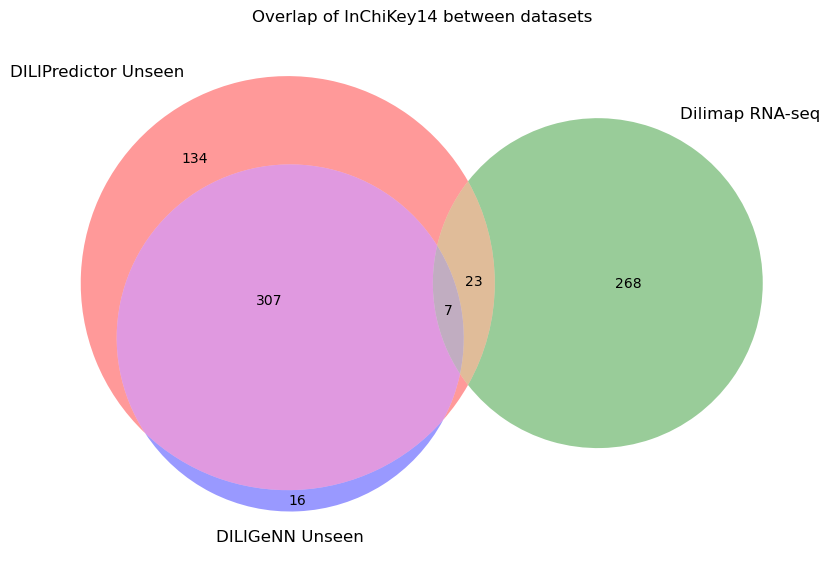

DILIPredictor unseen compounds: 471
DMAP transcriptomics smiles: 299
DILIGeNN unseen compounds: 331

DILIPredictor Unseen & DMAP overlap: 30
DILIPredictor Unseen & DILiGeNN Unseen overlap: 314
DILiGeNN Unseen & DMAP overlap: 8
DILIPredictor Unseen & DILiGeNN Unseen overlap & DMAP: 7


In [60]:
## DILIPR vs DILIGeNN overlap
# Plot overlap between all_dilipr_seen_inchikey14, df_std_filtered['InChiKey14'] and df_dg['InChiKey14']


# Convert to sets for overlap analysis
dilipr_set = set(dilipr_predictions.index)
dmap_rnaseq = set(df_res_all.index)
diligenn_set = set(combined_df.compound_name)

# Create Venn diagram
plt.figure(figsize=(10, 8))
venn = venn3(
    [dilipr_set, dmap_rnaseq, diligenn_set],
    ('DILIPredictor Unseen', 'Dilimap RNA-seq', 'DILIGeNN Unseen'),
)

plt.title('Overlap of InChiKey14 between datasets')
plt.show()

# Print overlap statistics
print(f'DILIPredictor unseen compounds: {len(dilipr_set)}')
print(f'DMAP transcriptomics smiles: {len(dmap_rnaseq)}')
print(f'DILIGeNN unseen compounds: {len(diligenn_set)}')
print()

# Calculate intersections
dilipr_dmap_overlap = dilipr_set & dmap_rnaseq
dilipr_dg_overlap = dilipr_set & diligenn_set
dmap_dg_overlap = dmap_rnaseq & diligenn_set
all_three_overlap = dilipr_set & dmap_rnaseq & diligenn_set

print(f'DILIPredictor Unseen & DMAP overlap: {len(dilipr_dmap_overlap)}')
print(f'DILIPredictor Unseen & DILiGeNN Unseen overlap: {len(dilipr_dg_overlap)}')
print(f'DILiGeNN Unseen & DMAP overlap: {len(dmap_dg_overlap)}')
print(
    f'DILIPredictor Unseen & DILiGeNN Unseen overlap & DMAP: {len(all_three_overlap)}'
)

In [61]:
overlap_cmpds = set(df_clean.compound_name).intersection(set(combined_df.compound_name))
overlap_df = df_clean[df_clean.index.isin(overlap_cmpds)].copy()
# Add columns from combined_df for warmstart model predictions
overlap_df = overlap_df.merge(
    combined_df[
        ['compound_name', 'DILIGeNN_avg_prob_warmstart', 'DILIGeNN_mode_pred_warmstart']
    ],
    on='compound_name',
    how='left',
)
overlap_df.head()

,LTKBID,compound_name,DILIrank,label_section,severity_class,DILIst,roa,source,livertox_score,livertox_primary_classification,...,livertox_mechanism_summary,InChiKey14,label,DILIPredictor_prediction,DILIPredictor_binary,DILIPredictor_probability,True_label,True_label_numeric,DILIGeNN_avg_prob_warmstart,DILIGeNN_mode_pred_warmstart
0,LT00964,Anagrelide,Ambiguous DILI-concern,Warnings and precautions,3.0,NaN,NaN,DILIrank,E*,Hematologic,...,NaN,OTBXOEAOVRKTNQ,0,DILI,True,0.7810926747670023,False,0,0.876281,1.0
1,LT01195,Aprepitant,Ambiguous DILI-concern,Adverse reactions,3.0,NaN,NaN,DILIrank,E,Gastrointestinal,...,NaN,ATALOFNDEOCMKK,0,DILI,True,0.7342626234579888,False,0,0.357398,0.0
2,LT00707,Butabarbital,Ambiguous DILI-concern,Adverse reactions,3.0,NaN,NaN,DILIrank,E,CNS,...,NaN,ZRIHAIZYIMGOAB,0,No DILI,False,0.43585037248699443,False,0,0.909950,1.0
3,LT01048,Cevimeline,Ambiguous DILI-concern,Adverse reactions,3.0,NaN,NaN,DILIrank,E,Opthalmologic,...,NaN,WUTYZMFRCNBCHQ,0,No DILI,False,0.5858185692685399,False,0,0.499214,0.0
4,LT00065,Chenodiol,Ambiguous DILI-concern,Warnings and precautions,8.0,NaN,NaN,DILIrank,E*,Gastrointestinal,...,NaN,RUDATBOHQWOJDD,0,No DILI,False,0.5862837665853369,False,0,0.747384,1.0


In [62]:
overlap_df.DILI_label_binary.value_counts()

DILI_label_binary
No DILI    269
DILI        45
Name: count, dtype: int64

In [63]:
# overlap_df.to_csv('./insilico_benchmarks/predictions/benchmark_dilipr_diligenn_314_predictions.csv')


Model Performance Comparison:


,Model,Balanced Accuracy,Specificity,Sensitivity
0,DILIGeNN Warm Start (GraphSAGE),0.562,0.279,0.844
1,DILIPredictor,0.545,0.290,0.800


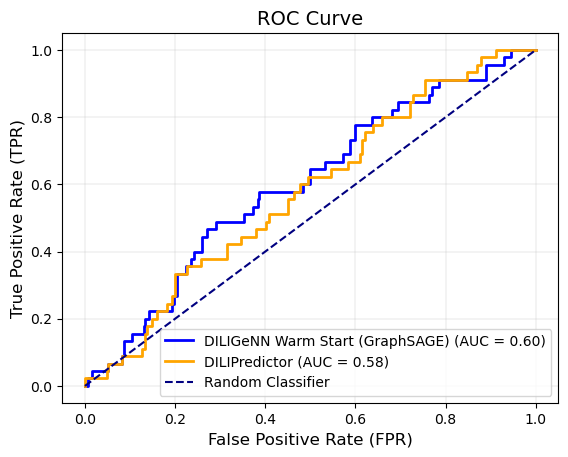

In [64]:
# Use overlap_df which contains compounds present in both datasets
df = overlap_df.copy()

# Calculate performance for DILIGeNN Warm Start
diligenn_warmstart_performance = calculate_comprehensive_metrics(
    df, 'True_label', ['DILIGeNN_mode_pred_warmstart']
)

# Calculate performance for DILIPredictor
dilipr_performance = calculate_comprehensive_metrics(
    df, 'True_label', ['DILIPredictor_binary']
)

diligenn_numeric_cols = diligenn_warmstart_performance.select_dtypes(
    include=[np.number]
).columns
dilipr_numeric_cols = dilipr_performance.select_dtypes(include=[np.number]).columns

# Calculate AUROC scores
diligenn_warmstart_auroc = roc_auc_score(
    df['True_label_numeric'], df['DILIGeNN_avg_prob_warmstart']
)
dilipr_auroc = roc_auc_score(df['True_label_numeric'], df['DILIPredictor_probability'])

# Create performance summaries
diligenn_warmstart_summary = pd.DataFrame(
    {
        'Model': ['DILIGeNN Warm Start (GraphSAGE)'],
        **{
            col: [f'{diligenn_warmstart_performance[col].iloc[0]:.3f}']
            for col in diligenn_numeric_cols
        },
    }
)

dilipr_summary = pd.DataFrame(
    {
        'Model': ['DILIPredictor'],
        **{
            col: [f'{dilipr_performance[col].iloc[0]:.3f}']
            for col in dilipr_numeric_cols
        },
    }
)

# Combine summaries
combined_summary = pd.concat(
    [diligenn_warmstart_summary, dilipr_summary], ignore_index=True
)

print('\nModel Performance Comparison:')
display(combined_summary)

# Plot ROC curves for both models
plot_roc_curves(
    df,
    'True_label',
    ['DILIGeNN_avg_prob_warmstart', 'DILIPredictor_probability'],
    model_names=['DILIGeNN Warm Start (GraphSAGE)', 'DILIPredictor'],
)

## 6. Run TxGemma on 715 unseen smiles 

### 6.1 Load data and identify unseen subset using InChiKey14 and SMILES

In [65]:
df_txg = pd.read_csv('./insilico_benchmarks/smiles_data/txgemma_train.csv')

In [66]:
df_txg['InChiKey14'] = [smiles_to_inchikey14(smiles) for smiles in df_txg['Drug']]
df_txg.head()

,Drug_ID,Drug,Y,InChiKey14
0,187.0,CC(=O)OCC[N+](C)(C)C,0.0,OIPILFWXSMYKGL
1,247.0,C[N+](C)(C)CC(=O)[O-],0.0,KWIUHFFTVRNATP
2,298.0,O=C(NC(CO)C(O)c1ccc([N+](=O)[O-])cc1)C(Cl)Cl,0.0,WIIZWVCIJKGZOK
3,338.0,O=C(O)c1ccccc1O,0.0,YGSDEFSMJLZEOE
4,444.0,CC(NC(C)(C)C)C(=O)c1cccc(Cl)c1,0.0,SNPPWIUOZRMYNY


In [67]:
# 1. Direct SMILES matching (intersection)
smiles_overlap_values = set(cellarity_smiles_dili_dataset['smiles']).intersection(
    set(df_txg['Drug'])
)
smiles_overlap_mask = cellarity_smiles_dili_dataset['smiles'].isin(
    smiles_overlap_values
)

# 2. InChiKey14 based overlap (intersection)
cellarity_inchikey14_lower = cellarity_smiles_dili_dataset['InChiKey14'].astype(str)
df_txg_inchikey14_lower = df_txg['InChiKey14'].astype(str)
inchikey14_overlap_values = set(cellarity_inchikey14_lower).intersection(
    set(df_txg_inchikey14_lower)
)
inchikey14_overlap_mask = cellarity_inchikey14_lower.isin(inchikey14_overlap_values)

overlap_mask = smiles_overlap_mask | inchikey14_overlap_mask
txgemma_unseeen_smiles = cellarity_smiles_dili_dataset[~overlap_mask].copy()
print(f'Number of unseen compounds: {len(txgemma_unseeen_smiles)}')

Number of unseen compounds: 715


Overlap between txgemma_unseeen_smiles and df_res_all: 97 compounds


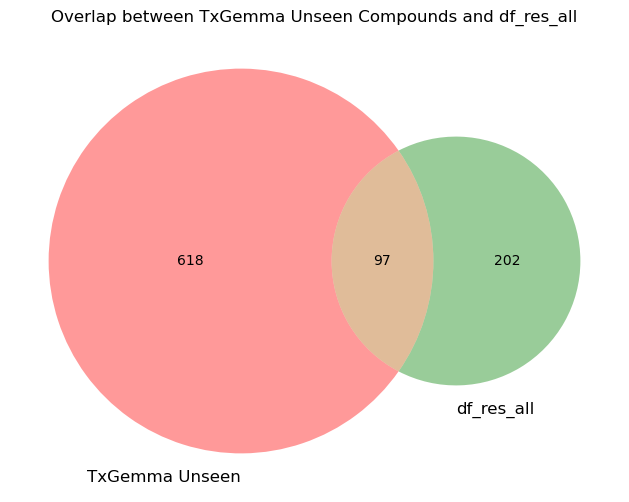

In [68]:
# Plot overlap between txgemma_unseeen_smiles and df_res_all
overlap_with_df_res_all = set(txgemma_unseeen_smiles['compound_name']).intersection(
    set(df_res_all['compound_name'])
)
print(
    f'Overlap between txgemma_unseeen_smiles and df_res_all: {len(overlap_with_df_res_all)} compounds'
)

# Create a visualization of the overlap

plt.figure(figsize=(8, 6))
venn2(
    [set(txgemma_unseeen_smiles['compound_name']), set(df_res_all['compound_name'])],
    set_labels=('TxGemma Unseen', 'df_res_all'),
)
plt.title('Overlap between TxGemma Unseen Compounds and df_res_all')
plt.show()

In [69]:
# txgemma_unseeen_smiles.to_csv('./insilico_benchmarks/smiles_data/unseen_smiles_txgemma_715.csv')

### 6.2 Run predictions using reproducible scripts


- See ./insilico_benchmarks/run_txgemma_dili.py and Readme for more details
- Results are available here: ./insilico_benchmarks/predictions/benchmark_txgemma_all_models_predictions.csv

In [70]:
txgemma_dili_predictions = pd.read_csv(
    './insilico_benchmarks/predictions/benchmark_txgemma_all_variants_715_predictions.csv',
    index_col=0,
)

txgemma_dili_predictions['True_label'] = txgemma_dili_predictions[
    'DILI_label_binary'
].map({'DILI': True, 'No DILI': False})
label_mapping = {'DILI': 1, 'No DILI': 0}
txgemma_dili_predictions['True_label_numeric'] = txgemma_dili_predictions[
    'DILI_label_binary'
].map(label_mapping)
txgemma_dili_predictions.head()

,LTKBID,compound_name,DILIrank,label_section,severity_class,DILIst,roa,source,livertox_score,livertox_primary_classification,...,livertox_mechanism_summary,InChiKey14,TxGemma2B_predicted_DILI_Label_output,TxGemma9B_predicted_DILI_Label_output,TxGemma27B_predicted_DILI_Label_output,TxGemma2B_predicted_DILI_Label,TxGemma9B_predicted_DILI_Label,TxGemma27B_predicted_DILI_Label,True_label,True_label_numeric
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
4-aminosalicylic acid,LT00505,4-aminosalicylic acid,Most-DILI-Concern,Warnings and precautions,5.0,NaN,Oral,DILIrank,NaN,NaN,...,NaN,WUBBRNOQWQTFEX,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,DILI,DILI,DILI,True,1
Acetaminophen,LT00004,Acetaminophen,Most-DILI-Concern,Warnings and precautions,5.0,NaN,Oral,DILIrank,A [HD],Analgesic,...,"CYP, Hypersensitivity",RZVAJINKPMORJF,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,DILI,DILI,DILI,True,1
Acetylcholine chloride,LT02096,Acetylcholine chloride,No-DILI-Concern,No match,0.0,NaN,Oral,DILIrank,NaN,NaN,...,NaN,JUGOREOARAHOCO,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,No DILI,DILI,No DILI,False,0
Acetylcysteine,LT01041,Acetylcysteine,No-DILI-Concern,No match,0.0,NaN,Oral,DILIrank,E,Toxicology,...,NaN,PWKSKIMOESPYIA,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,DILI,DILI,DILI,False,0
Acitretin,LT01042,Acitretin,Most-DILI-Concern,Box warning,5.0,NaN,Oral,DILIrank,B,Dermatologic,...,"Hepatitis, Cholestasis/Biliary, Hypersensitivity",IHUNBGSDBOWDMA,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,DILI,DILI,DILI,True,1


### 6.3 Evaluate predictions from TxGemma 2B predict, 9B predict and 27B predict variants on unseen smiles (715 compounds)

In [71]:
y_true = txgemma_dili_predictions['True_label'].astype(str)
y_true_bool = (y_true == 'True').astype(bool)

print('\nClass distribution in true labels:')
print(pd.Series(y_true).value_counts())

# Define prediction columns for TxGemma models and ToxPredictor
prediction_columns = [
    'Predicted_label',
    'TxGemma2B_predicted_DILI_Label',
    'TxGemma9B_predicted_DILI_Label',
    'TxGemma27B_predicted_DILI_Label',
]

# Preprocess TxGemma predictions before calling calculate_comprehensive_metrics
for pred_col in prediction_columns:
    if pred_col in txgemma_dili_predictions.columns and 'TxGemma' in pred_col:
        txgemma_dili_predictions[pred_col] = (
            txgemma_dili_predictions[pred_col].astype(str).str.upper() == 'DILI'
        ).astype(str)

# Calculate comprehensive metrics
performance_df = calculate_comprehensive_metrics(
    txgemma_dili_predictions,
    'True_label',
    prediction_columns,
)
performance_df['Model'] = performance_df['Model'].replace(
    {
        'Predicted Label': 'ToxPredictor',
        'Txgemma2B Predicted Dili Label': 'TxGemma 2B predict',
        'Txgemma9B Predicted Dili Label': 'TxGemma 9B predict',
        'Txgemma27B Predicted Dili Label': 'TxGemma 27B predict',
    }
)

print('\nTxGemma Model Performance:')
display(performance_df)


Class distribution in true labels:
True_label
False    537
True     178
Name: count, dtype: int64

TxGemma Model Performance:


,Model,Balanced Accuracy,Specificity,Sensitivity
0,TxGemma 2B predict,0.494,0.184,0.803
1,TxGemma 9B predict,0.468,0.223,0.713
2,TxGemma 27B predict,0.470,0.372,0.567


### 6.4 Evaluate predictions from TxGemma 2B predict, 9B predict and 27B predict against other insilico methods (303 compounds)

Overlap between TxGemma and DiliMap: 97 compounds
Overlap between TxGemma, DILIPredictor and DILIGeNN unseen smiles: 303 compounds
Overlap between DILIMap and Unseen smiles overlap of DILIGeNN and DILIPredictor: 7 compounds


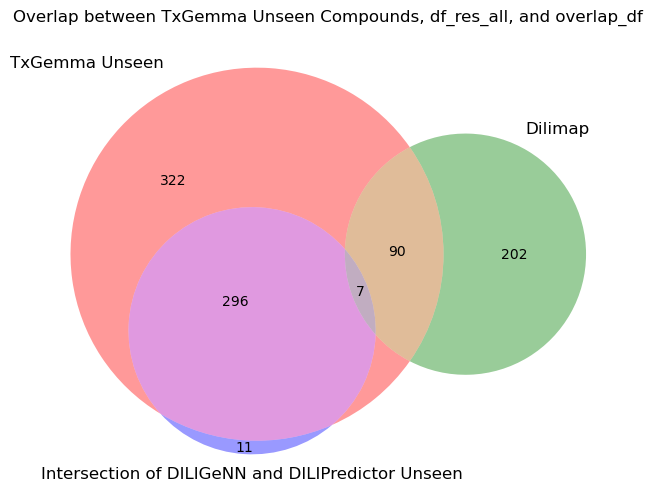

In [72]:
# Plot overlap between txgemma_unseeen_smiles, overlap_df and df_res_all
overlap_with_df_res_all = set(txgemma_dili_predictions['compound_name']).intersection(
    set(df_res_all['compound_name'])
)
print(f'Overlap between TxGemma and DiliMap: {len(overlap_with_df_res_all)} compounds')


# Add overlap_df to the mix
overlap_with_overlap_df = set(txgemma_dili_predictions['compound_name']).intersection(
    set(overlap_df['compound_name'])
)
print(
    f'Overlap between TxGemma, DILIPredictor and DILIGeNN unseen smiles: {len(overlap_with_overlap_df)} compounds'
)

# Find overlap between df_res_all and overlap_df
overlap_df_res_all_overlap_df = set(df_res_all['compound_name']).intersection(
    set(overlap_df['compound_name'])
)
print(
    f'Overlap between DILIMap and Unseen smiles overlap of DILIGeNN and DILIPredictor: {len(overlap_df_res_all_overlap_df)} compounds'
)

# Create a visualization of the three-way overlap

plt.figure(figsize=(8, 6))
venn3(
    [
        set(txgemma_dili_predictions['compound_name']),
        set(df_res_all['compound_name']),
        set(overlap_df['compound_name']),
    ],
    set_labels=(
        'TxGemma Unseen',
        'Dilimap',
        'Intersection of DILIGeNN and DILIPredictor Unseen',
    ),
)
plt.title('Overlap between TxGemma Unseen Compounds, df_res_all, and overlap_df')
plt.show()

In [73]:
# Subset overlap_df and txgemma_unseeen_smiles to the 303 compounds in overlap_with_overlap_df
overlap_df_subset = overlap_df[
    overlap_df['compound_name'].isin(overlap_with_overlap_df)
].copy()
txgemma_subset = txgemma_dili_predictions[
    txgemma_dili_predictions['compound_name'].isin(overlap_with_overlap_df)
].copy()

# Create new dataframe starting with overlap_df_subset
benchmark_df = overlap_df_subset.copy()

# Add TxGemma predictions to the benchmark dataframe
txgemma_cols = [
    'TxGemma2B_predicted_DILI_Label',
    'TxGemma9B_predicted_DILI_Label',
    'TxGemma27B_predicted_DILI_Label',
]
for col in txgemma_cols:
    if col in txgemma_subset.columns:
        benchmark_df[col] = benchmark_df['compound_name'].map(
            txgemma_subset.set_index('compound_name')[col]
        )

y_true = benchmark_df['True_label'].astype(str)
y_true_bool = (y_true == 'True').astype(bool)

print('\nClass distribution in true labels:')
print(pd.Series(y_true).value_counts())

# Define prediction columns for TxGemma models, DILIPredictor and DILIGeNN
prediction_columns = [
    'DILIPredictor_binary',
    'DILIGeNN_mode_pred_warmstart',
    'TxGemma2B_predicted_DILI_Label',
    'TxGemma9B_predicted_DILI_Label',
    'TxGemma27B_predicted_DILI_Label',
]

# Calculate comprehensive metrics (excluding AUC/AUROC)
performance_df = calculate_comprehensive_metrics(
    benchmark_df,
    'True_label',
    prediction_columns,
)
performance_df['Model'] = performance_df['Model'].replace(
    {
        'Dilipredictor Binary': 'DILIPredictor',
        'Diligenn Mode Pred Warmstart': 'DILIGeNN Warm Start (GraphSAGE)',
        'Txgemma2B Predicted Dili Label': 'TxGemma 2B predict',
        'Txgemma9B Predicted Dili Label': 'TxGemma 9B predict',
        'Txgemma27B Predicted Dili Label': 'TxGemma 27B predict',
    }
)

print('\nModel Performance Comparison:')
display(performance_df)


Class distribution in true labels:
True_label
False    261
True      42
Name: count, dtype: int64

Model Performance Comparison:


,Model,Balanced Accuracy,Specificity,Sensitivity
0,DILIPredictor,0.553,0.272,0.833
1,DILIGeNN Warm Start (GraphSAGE),0.576,0.272,0.881
2,TxGemma 2B predict,0.493,0.153,0.833
3,TxGemma 9B predict,0.423,0.180,0.667
4,TxGemma 27B predict,0.410,0.272,0.548


### 6.5 Benchmark TxGemma 2B predict, 9B predict and 27B predict against ToxPredictor (97 compounds)

In [74]:
df_res_all_subset = df_res_all[
    ~(
        (df_res_all.compound_name == 'Chlorpromazine')
        & (df_res_all.Batch == 'cross-validation')
    )
].copy()

In [75]:
overlap_with_df_res_all = set(txgemma_unseeen_smiles['compound_name']).intersection(
    set(df_res_all['compound_name'])
)
df_res_all_subset = df_res_all_subset[
    df_res_all_subset.index.isin(overlap_with_df_res_all)
].copy()
txgemma_dmap = txgemma_dili_predictions.copy()

txgemma_dmap = txgemma_dmap[txgemma_dmap.index.isin(overlap_with_df_res_all)].copy()
# Update txgemma_dmap with values from df_res_all
for col in ['True_label', 'Predicted_label', 'MOS_ToxPredictor']:
    txgemma_dmap[col] = txgemma_dmap['compound_name'].map(
        df_res_all_subset.set_index('compound_name')[col]
    )

txgemma_dmap.head()

,LTKBID,compound_name,DILIrank,label_section,severity_class,DILIst,roa,source,livertox_score,livertox_primary_classification,...,TxGemma2B_predicted_DILI_Label_output,TxGemma9B_predicted_DILI_Label_output,TxGemma27B_predicted_DILI_Label_output,TxGemma2B_predicted_DILI_Label,TxGemma9B_predicted_DILI_Label,TxGemma27B_predicted_DILI_Label,True_label,True_label_numeric,Predicted_label,MOS_ToxPredictor
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Acetaminophen,LT00004,Acetaminophen,Most-DILI-Concern,Warnings and precautions,5.0,NaN,Oral,DILIrank,A [HD],Analgesic,...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,True,True,True,True,1,True,15.116015
Alaproclate,LT02213,Alaproclate,Most-DILI-Concern,Withdrawn,8.0,NaN,Oral,DILIrank,NaN,NaN,...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,False,False,False,True,1,True,1.593458
Almotriptan,LT01053,Almotriptan,No-DILI-Concern,No match,0.0,NaN,Oral,DILIrank,E,CNS,...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,False,True,True,False,0,False,300.000000
Amiodarone,LT00046,Amiodarone,Most-DILI-Concern,Box warning,8.0,NaN,Oral,DILIrank,A,Cardiovascular,...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,True,True,False,True,1,True,6.453200
Amoxicillin,LT00507,Amoxicillin,Less-DILI-Concern,Adverse reactions,5.0,NaN,Oral,DILIrank,B,Antimicrobial,...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,Prompt:\nInstructions: Answer the following qu...,True,True,True,True,1,True,71.093220


In [76]:
y_true = txgemma_dmap['True_label'].astype(str)
y_true_bool = (y_true == 'True').astype(bool)

print('\nClass distribution in true labels:')
print(pd.Series(y_true).value_counts())

# Define prediction columns for TxGemma models and ToxPredictor
prediction_columns = [
    'Predicted_label',
    'TxGemma2B_predicted_DILI_Label',
    'TxGemma9B_predicted_DILI_Label',
    'TxGemma27B_predicted_DILI_Label',
]

# Calculate comprehensive metrics
performance_df = calculate_comprehensive_metrics(
    txgemma_dmap,
    'True_label',
    prediction_columns,
)
performance_df['Model'] = performance_df['Model'].replace(
    {
        'Predicted Label': 'ToxPredictor',
        'Txgemma2B Predicted Dili Label': 'TxGemma 2B predict',
        'Txgemma9B Predicted Dili Label': 'TxGemma 9B predict',
        'Txgemma27B Predicted Dili Label': 'TxGemma 27B predict',
    }
)

print('\nTxGemma Model Performance:')
display(performance_df)


Class distribution in true labels:
True_label
True     62
False    35
Name: count, dtype: int64

TxGemma Model Performance:


,Model,Balanced Accuracy,Specificity,Sensitivity
0,ToxPredictor,0.808,0.857,0.758
1,TxGemma 2B predict,0.512,0.314,0.710
2,TxGemma 9B predict,0.579,0.400,0.758
3,TxGemma 27B predict,0.600,0.571,0.629


In [77]:
txgemma_dmap.TxGemma27B_predicted_DILI_Label.value_counts()

TxGemma27B_predicted_DILI_Label
True     54
False    43
Name: count, dtype: int64

In [78]:
txgemma_dmap[txgemma_dmap.True_label == 'True'][
    'TxGemma27B_predicted_DILI_Label'
].value_counts()

TxGemma27B_predicted_DILI_Label
True     39
False    23
Name: count, dtype: int64

In [79]:
txgemma_dmap[txgemma_dmap.True_label == 'True']['Predicted_label'].value_counts()

Predicted_label
True     47
False    15
Name: count, dtype: int64

In [80]:
txgemma_dmap[txgemma_dmap.True_label == 'False'][
    'TxGemma27B_predicted_DILI_Label'
].value_counts()

TxGemma27B_predicted_DILI_Label
False    20
True     15
Name: count, dtype: int64

In [81]:
txgemma_dmap[txgemma_dmap.True_label == 'False']['Predicted_label'].value_counts()

Predicted_label
False    30
True      5
Name: count, dtype: int64